# $visit_{n-1} - visit_{n} \rightarrow fatigue_{n-1} - fatigue_{n}$
$\Delta visit \rightarrow \Delta fatigue$ \
Finds difference from **previous** visit to current visit **using weekly DMOs**

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.train.train_regression_xv import LSTMRegressionXV
from src.core.data_transforms import Transform


import torch

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [5]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [ ]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [9]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [10]:
#dmo_data = dmo_data.mean(axis=2)

In [11]:
print(dmo_data.shape)
print(dmo_labels.shape)

torch.Size([428, 4, 7, 25])
torch.Size([428, 4, 1])


In [12]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [13]:
def format_input_data_delta_visit(input_data):
    if len(input_data.shape) < 4:
            input_data = input_data.unsqueeze(dim=0)

    patients, visits, days, features = input_data.shape

    delta_visits = torch.zeros(patients, visits - 1, days, features)
    for patient in range(patients):
        
        delta_visits[patient] = input_data[patient, 1:] - input_data[patient, :-1]

    return delta_visits

def format_label_data_delta_visit(label_data):
    patients, visits, labels = label_data.shape
    
    delta_labels = torch.zeros(patients, (visits - 1), labels)
    for patient in range(patients):
        delta_labels[patient] = label_data[patient, 1:] - label_data[patient, :-1]

    return delta_labels

In [14]:
dmo_data = format_input_data_delta_visit(dmo_data)
dmo_labels = format_label_data_delta_visit(dmo_labels)

In [15]:
dmo_data = dmo_data.mean(axis=2)

In [16]:
dmo_data.shape

torch.Size([428, 3, 25])

In [17]:
xv_trainer = LSTMRegressionXV(dmo_data, dmo_labels, config, device, k=K_FOLDS)
prediction, actual = xv_trainer.train_cross_validation()

Testing loss: 0.03969623024264971
<class 'list'>
[tensor([[-0.0933],
        [-0.0267],
        [ 0.0041]]), tensor([[ 0.0606],
        [-0.1837],
        [ 0.2591]]), tensor([[-0.0140],
        [ 0.1081],
        [-0.3147]]), tensor([[0.0079],
        [0.0442],
        [0.0567]]), tensor([[-0.0134],
        [-0.0296],
        [ 0.0835]]), tensor([[-0.1369],
        [ 0.2922],
        [-0.0914]]), tensor([[ 0.0141],
        [-0.0282],
        [-0.2290]]), tensor([[0.0051],
        [0.0268],
        [0.0106]]), tensor([[-0.0053],
        [-0.0222],
        [ 0.1050]]), tensor([[-0.0371],
        [ 0.0816],
        [ 0.0843]]), tensor([[-0.0101],
        [ 0.0051],
        [-0.0272]]), tensor([[-0.0280],
        [ 0.0372],
        [ 0.0008]]), tensor([[0.0781],
        [0.1022],
        [0.2000]]), tensor([[-0.0138],
        [-0.0653],
        [-0.0145]]), tensor([[-0.0059],
        [-0.0218],
        [ 0.0285]]), tensor([[ 0.0231],
        [ 0.0010],
        [-0.1097]]), tensor([[-0.122

In [18]:
prediction = torch.concatenate(prediction).flatten().reshape(dmo_labels.shape)
prediction = label_normaliser.scaler_inverse_labels(prediction).flatten()
prediction.shape

torch.Size([1284])

In [19]:
actual = torch.concatenate(actual).flatten().reshape(dmo_labels.shape)
actual = label_normaliser.scaler_inverse_labels(actual).flatten()
actual.shape

torch.Size([1284])

In [20]:
print(xv_trainer.R2_values)

[-0.5607365369796753, -0.29955434799194336, -0.3981657028198242, -0.414553165435791, -0.6184754371643066]


All metrics: {'accuracy': 0.006230529595015576, 'Mean Squared Error': 47.540870666503906, 'Mean Absolute Error': 5.16227388381958, 'R^2': -0.44593407866304546}


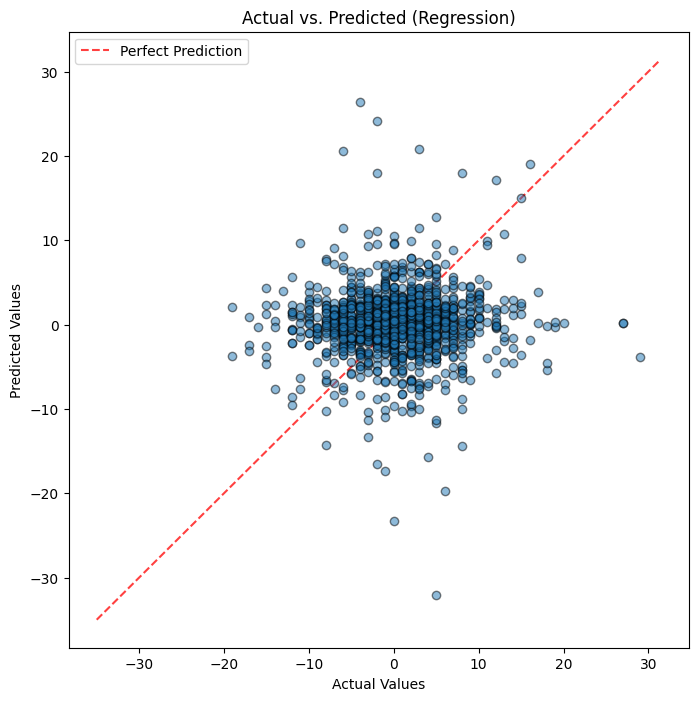

In [21]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
